In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
df = pd.read_csv("Tesla.csv", parse_dates=["Date"])
df.sort_values("Date", inplace=True)

In [3]:
data = df[["Close"]].values

In [4]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [5]:
def create_sequences(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_data, time_step)

In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [7]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

In [8]:
model.fit(X, y, epochs=20, batch_size=32, verbose=1)

Epoch 1/20

51/51 [==============================] - 7s 40ms/step - loss: 0.0410
Epoch 2/20
51/51 [==============================] - 2s 35ms/step - loss: 0.0052
Epoch 3/20
51/51 [==============================] - 2s 39ms/step - loss: 0.0044
Epoch 4/20
51/51 [==============================] - 2s 35ms/step - loss: 0.0040
Epoch 5/20
51/51 [==============================] - 2s 36ms/step - loss: 0.0040
Epoch 6/20
51/51 [==============================] - 2s 34ms/step - loss: 0.0036
Epoch 7/20
51/51 [==============================] - 2s 33ms/step - loss: 0.0035
Epoch 8/20
51/51 [==============================] - 2s 34ms/step - loss: 0.0031
Epoch 9/20
51/51 [==============================] - 2s 42ms/step - loss: 0.0035
Epoch 10/20
51/51 [==============================] - 2s 48ms/step - loss: 0.0032
Epoch 11/20
51/51 [==============================] - 2s 45ms/step - loss: 0.0032
Epoch 12/20
51/51 [==============================] - 2s 39ms/step - loss: 0.0030
Epoch 13/20
51/51 [=================

In [9]:
train_predict = model.predict(X)
train_predict = scaler.inverse_transform(train_predict.reshape(-1,1))
real_prices = scaler.inverse_transform(y.reshape(-1,1))

51/51 [==============================] - 2s 14ms/step


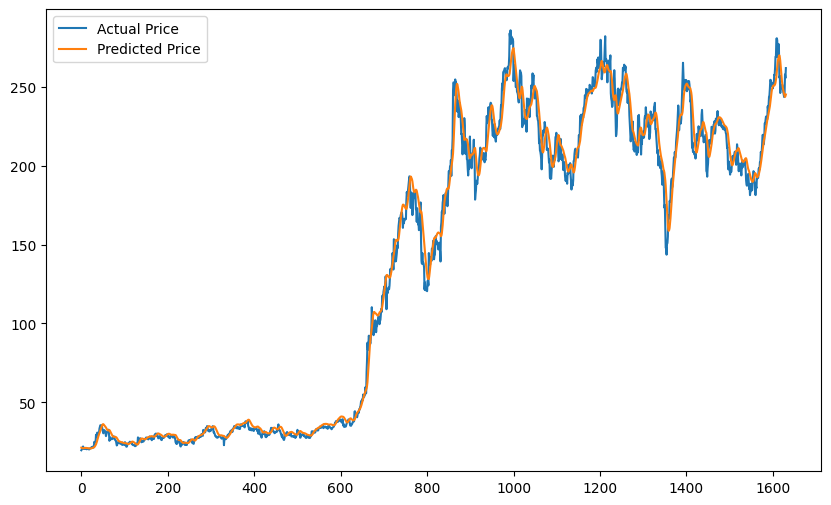

In [10]:
plt.figure(figsize=(10,6))
plt.plot(real_prices, label="Actual Price")
plt.plot(train_predict, label="Predicted Price")
plt.legend()
plt.show()